## 1. Preprocessing
### 1.1 Load library

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

array = np.ndarray

from itertools import product
import pandas as pd

### 1.2 Load ORL Dataset and Extended YaleB Dataset.
+ ORL dataset contains ten different images of each of 40 distinct subjects. For some subjects, the images were taken at different times, varying the lighting, facial expressions (open / closed eyes, smiling / not smiling) and facial details (glasses / no glasses). All the images were taken against a dark homogeneous background with the subjects in an upright, frontal position (with tolerance for some side movement). The size of each image is 92x112 pixels, with 256 grey levels per pixel. To further reduce the computation complexity, you can resize all images to 30x37 pixels.

+ Extended YaleB dataset contains 2414 images of 38 human subjects under 9 poses and 64 illumination conditions. All images are manually aligned, cropped, and then resized to 168x192 pixels. To further reduce the computation complexity, you can resize all images to 42x48 pixels.

In [4]:
root_ORL = 'data/ORL'
img_resize_ORL = (37,30)
root_YaleB = 'data/CroppedYaleB'
img_resize_YaleB = (48,42)

In [6]:
def load_data(root='data/CroppedYaleB', img_resize = (1,1)):
    """ 
    Load ORL (or Extended YaleB) dataset to numpy array.
    
    Args:
        root: path to dataset.
        reduce: scale factor for zooming out images.
        
    """ 
    images, labels = [], []

    for i, person in enumerate(sorted(os.listdir(root))):
        
        if not os.path.isdir(os.path.join(root, person)):
            continue
        
        for fname in os.listdir(os.path.join(root, person)):    
            
            # Remove background images in Extended YaleB dataset.
            if fname.endswith('Ambient.pgm'):
                continue
            
            if not fname.endswith('.pgm'):
                continue
                
            # load image.
            img = Image.open(os.path.join(root, person, fname))
            img = img.convert('L') # grey image.

            # reduce computation complexity.
            img = img.resize(img_resize)

            # TODO: preprocessing.

            # convert image to numpy array.
            img = np.asarray(img).reshape((-1,1)).astype(np.float32)
            img = img / 255.0  # normalization to [0,1]

            # collect data and label.
            images.append(img)
            labels.append(i)

    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)

    return images, labels

In [8]:
# Load ORL dataset.
ORL_X, ORL_Y = load_data(root=root_ORL, img_resize=img_resize_ORL)
print('ORL dataset: X.shape = {}, Y.shape = {}'.format(ORL_X.shape, ORL_Y.shape))

# Load Extended YaleB dataset.
YaleB_X, YaleB_Y = load_data(root=root_YaleB, img_resize = img_resize_YaleB)
print('Extended YalB dataset: X.shape = {}, Y.shape = {}'.format(YaleB_X.shape, YaleB_Y.shape))

ORL dataset: X.shape = (1110, 400), Y.shape = (400,)
Extended YalB dataset: X.shape = (2016, 2414), Y.shape = (2414,)


### 1.2 Dataset pre-show

In [11]:
# A function to show the examples in dataset.

def examples(dataset, n_rows = 5, n_cols = 10, img_resize = (1,1,1)):

    faces = dataset.T.reshape(img_resize)

    plt.figure(figsize=(n_cols, n_rows))
    plt.axis('off')

    for r in range(n_rows):
        for c in range(n_cols):

            index = r * 10 + c

            plt.subplot(n_rows, n_cols, index+1)
            plt.axis('off')
            plt.imshow(faces[index], cmap= "gray" )

        
    plt.show()

Some examples img of ORL dataset


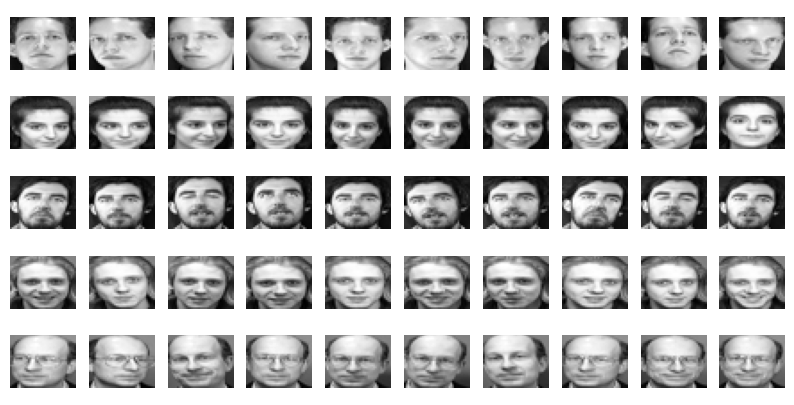

First 10 examples of y_train: [2 2 2 2 2 2 2 2 2 2]


In [13]:
print(f"Some examples img of ORL dataset")
examples(ORL_X, img_resize = (400,30,37))
print(f"First 10 examples of y_train: {ORL_Y[0:10]}")

Some examples img of YaleB dataset


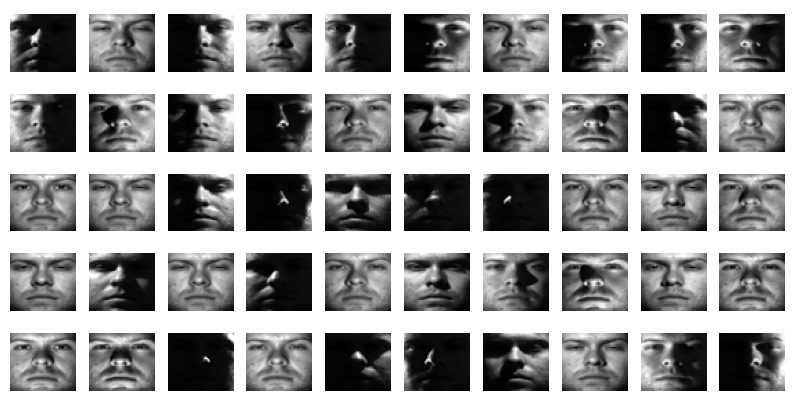

First 10 examples of y_train: [1 1 1 1 1 1 1 1 1 1]


In [15]:
print(f"Some examples img of YaleB dataset")
examples(YaleB_X, img_resize = (2414,42,48))
print(f"First 10 examples of y_train: {YaleB_Y[0:10]}")

## 2. Main NMF Algorithm

### 2.1 Standard NMF (L2 NMF) Algorithm

In [19]:
def nmf_standard(V, y, eps=1e-10, seed=0):
    """
    Standard NMF (L2 NMF)
    V: d * n non-negative matrix
    k: rank for factorization
    """
    d, n = V.shape

    # Initial iter matrix
    # Here rank is usually to choose close to the examples of dataset.
    k = len(np.unique(y))

    # init W, H
    np.random.seed(seed)
    W = np.random.random((d, k))
    H = np.random.random((k, n))

    diff = float('Inf')
    iters = 0

    # max iteration
    maxiter = 10

    while (iters < maxiter) and (diff > eps):
        # update H
        WH = np.dot(W, H)
        H_new = H * (np.dot(W.T, V)) / (np.dot(W.T, WH) + 1e-12)

        # update W
        WH = np.dot(W, H_new)
        W_new = W * (np.dot(V, H_new.T)) / (np.dot(W, np.dot(H_new, H_new.T)) + 1e-12)

        # non-negativity
        W_new = np.clip(W_new, 0, None)
        H_new = np.clip(H_new, 0, None)

        # check convergence
        diff_W = np.linalg.norm(W_new - W)
        diff_H = np.linalg.norm(H_new - H)
        diff = diff_W + diff_H

        # update W, H
        W, H = W_new, H_new

        iters += 1

    print(f"Converged after {iters} iterations, diff={diff:.3e}")
    return W, H

### 2.2 L2,1-Norm Based NMF Algorithm

In [22]:
# Function to check if the Matrix is positive or not.

def check_positive(X:array):
    if np.any(X<0):
        raise ValueError(f'The matrix {X} is not a Non-negative Matrix')

In [ ]:
# Algorithm

def L21_norm_based_NMF(X:array, y:array, name:str, 
                                random_state:int | None = 42,
                                convergence_criterion = 1e-7):
    '''
    
    '''
    check_positive(X)
    m,n = X.shape
    rng = np.random.default_rng(random_state)

    # In case to happen that the Denominator=0
    eps = 1e-12 

    # In case to happen the flustration.
    max_iter = 5000

    # Record the iteration
    history = []

    # Initial iter matrix
    # Here rank is usually to choose close to the examples of dataset.
    rank = len(np.unique(y))

    F = rng.random((m,rank))+1e-8 
    G = rng.random((rank,n))+1e-8

    
    for i in range(max_iter):

        # Compute D Matrix
        D_residual = X - F @ G
        D_denominator = np.sqrt(np.sum(D_residual*D_residual, axis = 0))+eps
        D = np.diag(1.0 / D_denominator)

        # Update F
        F_molecular = X @ D @ G.T
        F_denominator = F @ G @ D @ G.T + eps
        F *= F_molecular/F_denominator
        F = np.maximum(F,eps) # Make sure non-negative.

        # Update G
        G_molecular = F.T @ X @ D
        G_denominator = F.T @ F @ G @ D + eps
        G *= G_molecular/G_denominator
        G = np.maximum(G,eps) # Make sure non-negative.

        # Update residual
        residual = D_denominator
        history.append(np.sum(residual))

        if i > 0:
            convergence_new = abs(history[-1] - history[-2]) / (history[-2] + eps)
            if convergence_new < convergence_criterion:
                print('-')
                print(f'Using L_21_Norm_NMF_Algorithm on dataset {name}.')
                print(f'Reached the convergence criterion. Total iterative number: {i+1}.')
                print('-')
                break
        
        if i == max_iter - 1:
            print('-')
            print(f'Using L_21_Norm_NMF_Algorithm on dataset {name}.')
            print(f'Reached the max iteration. Last convergence rate: {convergence_new}.')
            print('-')

    return F, G
    

## 3. Evaluation Metrics




## 3.1 Add salt & pepper noise

Pre-show of noise plot.

In [28]:
# Add salt & pepper noise Algorithm

def add_salt_pepper(X, p, r, seed, vmax=1.0):
    """
    Args:
        X    : numpy array of shape (d, n), values in [0,1].
        p    : fraction of pixels to be corrupted per image.
        r    : fraction of corrupted pixels set to salt (vmax); the rest are pepper (0).
        seed : random seed (to be reproducible).
        vmax : maximum pixel value (default 1.0 after normalization).
    """
    d, n = X.shape
    np.random.seed(seed)
    Xn = X.copy()

    m = int(round(p * d))     # number of pixels to corrupt per column
    if m <= 0:
        return Xn
    k = int(round(r * m))     # number of salt pixels (set to vmax)

    for j in range(n):
        idx = np.random.choice(d, size=m, replace=False)
        # salt: set selected pixels to vmax
        Xn[idx[:k], j] = vmax
        # pepper: set the remaining to 0
        Xn[idx[k:], j] = 0.0
    return Xn

In [30]:
# Plot pre-show

def Noise_pre_show(root, img_resize, name:str):

    # Load dataset.
    print(f'==> Load {name} dataset ...')
    V_hat, Y_hat = load_data(root=root, img_resize = img_resize)
    print('V_hat.shape={}, Y_hat.shape={}'.format(V_hat.shape, Y_hat.shape))

    # Add salt & pepper noise.
    p, r = 0.2, 0.7 
    V = add_salt_pepper(V_hat, p=p, r=r, seed=0, vmax=1.0)

    # Derive a pure noise image (for visualization).
    V_noise = V - V_hat

    # Plot result.
    img_size = img_resize
    ind = 2  # index of demo image.

    plt.figure(figsize=(10,3))

    # Original
    plt.subplot(131)
    plt.imshow(V_hat[:,ind].reshape(img_size[1], img_size[0]), cmap=plt.cm.gray)
    plt.title('Image (Original)')

    # Noise only
    plt.subplot(132)
    plt.imshow(V_noise[:,ind].reshape(img_size[1], img_size[0]), cmap=plt.cm.gray)
    plt.title('Noise')

    # Noisy image
    plt.subplot(133)
    plt.imshow(V[:,ind].reshape(img_size[1], img_size[0]), cmap=plt.cm.gray)
    plt.title('Image (Noisy)')
    plt.show()

==> Load ORL dataset ...
V_hat.shape=(1110, 400), Y_hat.shape=(400,)


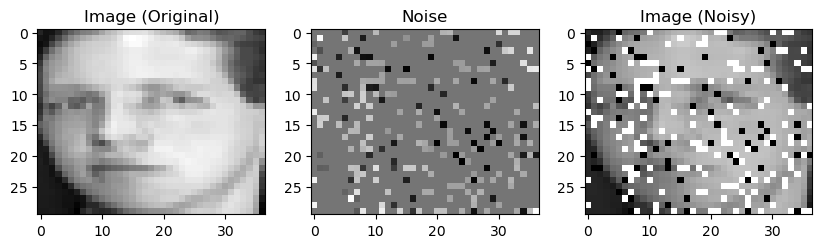

In [32]:
Noise_pre_show(root = root_ORL, img_resize=img_resize_ORL, name = "ORL")

==> Load YaleB dataset ...
V_hat.shape=(2016, 2414), Y_hat.shape=(2414,)


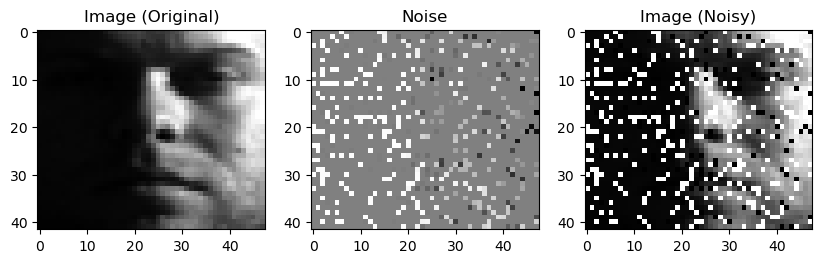

In [34]:
Noise_pre_show(root = root_YaleB, img_resize=img_resize_YaleB, name = "YaleB")

In [36]:
# Plot pre-show below different p and r.

def Noise_pre_show_pr(root, img_resize, name:str):
    
    print(f'==> Load {name} dataset ...')
    V_hat, Y_hat = load_data(root=root, img_resize = img_resize)
    print('V_hat.shape={}, Y_hat.shape={}'.format(V_hat.shape, Y_hat.shape))

    # Example index
    ind = 7
    img_size = img_resize

    # Original
    img_a = V_hat[:, ind].reshape(img_size[1], img_size[0])
    # p=0.2, r=0.1
    img_b = add_salt_pepper(V_hat, p=0.2, r=0.1, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])
    # p=0.2, r=0.7
    img_c = add_salt_pepper(V_hat, p=0.2, r=0.7, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])
    # p=0.4, r=0.1
    img_d = add_salt_pepper(V_hat, p=0.4, r=0.1, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])
    # p=0.4, r=0.7
    img_e = add_salt_pepper(V_hat, p=0.4, r=0.7, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])
    # p=0.6, r=0.1
    img_f = add_salt_pepper(V_hat, p=0.6, r=0.1, seed=0, vmax=1.0)[:, ind].reshape(img_size[1], img_size[0])

    plt.figure(figsize=(9, 6))
    plt.subplot(2,3,1); plt.imshow(img_a, cmap='gray'); plt.title("(a) p=0(Original)")
    plt.subplot(2,3,2); plt.imshow(img_b, cmap='gray'); plt.title("(b) p=0.2,r=0.1")
    plt.subplot(2,3,3); plt.imshow(img_c, cmap='gray'); plt.title("(c) p=0.2,r=0.7")
    plt.subplot(2,3,4); plt.imshow(img_d, cmap='gray'); plt.title("(d) p=0.4,r=0.1")
    plt.subplot(2,3,5); plt.imshow(img_e, cmap='gray'); plt.title("(e) p=0.4,r=0.7")
    plt.subplot(2,3,6); plt.imshow(img_f, cmap='gray'); plt.title("(f) p=0.6,r=0.1")
    plt.tight_layout()
    plt.show()

==> Load ORL dataset ...
V_hat.shape=(1110, 400), Y_hat.shape=(400,)


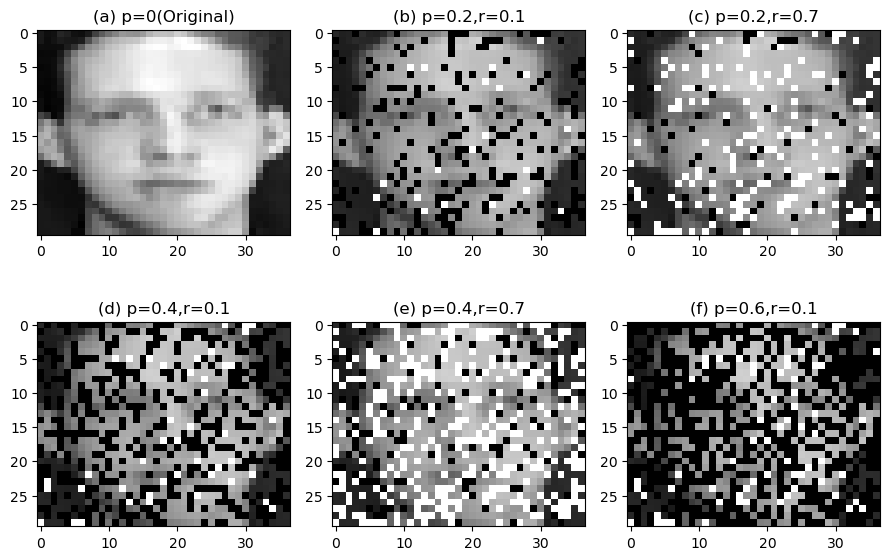

In [38]:
Noise_pre_show_pr(root = root_ORL, img_resize=img_resize_ORL, name = "ORL")

==> Load YaleB dataset ...
V_hat.shape=(2016, 2414), Y_hat.shape=(2414,)


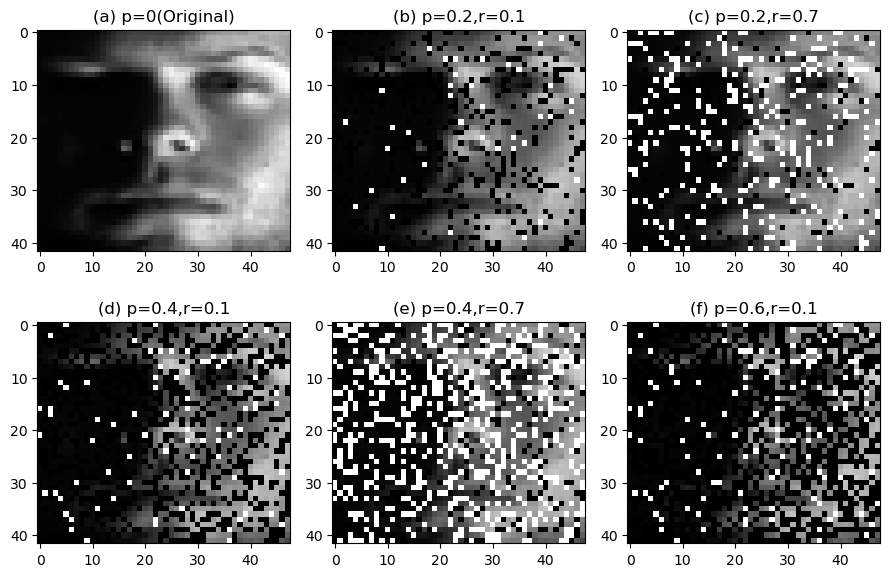

In [40]:
Noise_pre_show_pr(root = root_YaleB, img_resize=img_resize_YaleB, name = "YaleB")


### 3.1 Relative Reconstruction Errors (RRE)

To compare the robustness of different NMF algorithms, you can use the ```relative reconstruction errors```. Let $V$ denote the contaminated dataset (by adding noise), and $\hat{V}$
 denote the clean dataset. Let $W$ and $H$ denote the factorization results on $V$, the ``relative reconstruction errors`` then can be defined as follows:
\begin{equation}
    RRE = \frac{ \| \hat{V} - WH \|_F }{ \| \hat{V} \|_F}.
\end{equation}

In [47]:
# Compute Relative Reconstruction Error (RRE) for repeat NMF experiment n times
# Save records
try:
    rre_records
except NameError:
    rre_records = []
# Main function
def repeat_rre(p, r, method:str, name:str, ratio = 0.9, num=5, seed=0):
    """
    Origin_X : clean data matrix (d * n)
    p, r    : noise parameters
    k       : rank for NMF
    num     : number of repetitions
    seed    : random seed
    add_noise: function to add noise
    nmf_func : NMF function
    L_21_norm_based_NMF : L_21_norm_based_NMF function
    """
    scores = []

    if name == "ORL":
        Origin_X,Origin_y = load_data(root = root_ORL, img_resize = img_resize_ORL)
    if name == "YaleB":
        Origin_X,Origin_y = load_data(root = root_YaleB, img_resize = img_resize_YaleB)

    n_samples = Origin_X.shape[1]
    n_train = int(n_samples * ratio)

    for t in range(num):

        print('-')
        print(f'Start evaluate RRE in dataset {name} using {method} with p = {p}, r={r}.')

        # 90% sample
        rng = np.random.default_rng(seed=t)
        indices = rng.permutation(n_samples)

        # Collect the ratio of data.
        test_idx = indices[:n_train]
        X_test, y_test = Origin_X[:,test_idx], Origin_y[test_idx]
        V_hat, Y_hat = X_test, y_test

        # add salt & pepper noise
        V_noisy = add_salt_pepper(V_hat, p=p, r=r, seed=seed+t, vmax=1.0)

        # factorize noisy data
        if method == "L2_norm_NMF":
            W, H = nmf_standard(V_noisy, Y_hat, eps=1e-7, seed=seed+t)
        if method == "L21_norm_based_NMF":
            W, H, history = L21_norm_based_NMF(X = V_noisy, y = Y_hat, name = name)

        # compute RRE against clean data
        rre = np.linalg.norm(V_hat - W.dot(H),'fro') / np.linalg.norm(V_hat,'fro')
        print(f'Random No.{t+1} times, RRE score: RRE = {rre}')
        scores.append(rre)
    
    mean = float(np.mean(scores))
    std = float(np.std(scores))
    
    print(f'RRE mean on dataset {name} using {method} with p = {p}, r={r}: {float(np.mean(scores))}')
    print(f'RRE std on dataset {name} using {method} with p = {p}, r={r}: {float(np.std(scores))}')

    rre_records.append({
        "dataset": name,
        "nmf_method": method,
        "p": float(p),
        "r": float(r),
        "rre_mean": mean,
        "rre_sd": std,
    })

    return mean, std

In [49]:
# Function to evaluate all dataset and algorithm rre and record

datasets = ["ORL", "YaleB"]
methods = ["L2_norm_NMF","L21_norm_based_NMF"] # 
ps = [0.2,0.4,0.6]
rs = [0.1,0.4,0.7]

results = {}

for p, r, name, method in product(ps, rs, datasets, methods):
    mean,std = repeat_rre(p = p, r = r, method=method, name=name)
    results.setdefault((name, method, "mean"), []).append(mean)
    results.setdefault((name, method, "std"), []).append(std)
    

-
Start evaluate RRE in dataset ORL using L2_norm_NMF with p = 0.2, r=0.1.
Converged after 10 iterations, diff=2.313e+00
Random No.1 times, RRE score: RRE = 0.3207184352233757
-
Start evaluate RRE in dataset ORL using L2_norm_NMF with p = 0.2, r=0.1.
Converged after 10 iterations, diff=2.299e+00
Random No.2 times, RRE score: RRE = 0.31990223564942666
-
Start evaluate RRE in dataset ORL using L2_norm_NMF with p = 0.2, r=0.1.
Converged after 10 iterations, diff=2.358e+00
Random No.3 times, RRE score: RRE = 0.32096221714910206
-
Start evaluate RRE in dataset ORL using L2_norm_NMF with p = 0.2, r=0.1.
Converged after 10 iterations, diff=2.351e+00
Random No.4 times, RRE score: RRE = 0.32024469722791077
-
Start evaluate RRE in dataset ORL using L2_norm_NMF with p = 0.2, r=0.1.
Converged after 10 iterations, diff=2.334e+00
Random No.5 times, RRE score: RRE = 0.32149177457859435
RRE mean on dataset ORL using L2_norm_NMF with p = 0.2, r=0.1: 0.3206638719656819
RRE std on dataset ORL using L2_no

In [61]:
# Summary rre records
df_rre = pd.DataFrame(
    rre_records,
    columns=["dataset", "nmf_method", "p", "r", "rre_mean", "rre_sd"]
).sort_values(["dataset", "nmf_method", "p", "r"])

print(df_rre)

   dataset          nmf_method    p    r  rre_mean    rre_sd
1      ORL  L21_norm_based_NMF  0.2  0.1  0.320782  0.000517
5      ORL  L21_norm_based_NMF  0.2  0.4  0.289907  0.000585
9      ORL  L21_norm_based_NMF  0.2  0.7  0.309868  0.000492
13     ORL  L21_norm_based_NMF  0.4  0.1  0.413878  0.000424
17     ORL  L21_norm_based_NMF  0.4  0.4  0.308297  0.000605
21     ORL  L21_norm_based_NMF  0.4  0.7  0.377838  0.001065
25     ORL  L21_norm_based_NMF  0.6  0.1  0.531275  0.000571
29     ORL  L21_norm_based_NMF  0.6  0.4  0.335583  0.000541
33     ORL  L21_norm_based_NMF  0.6  0.7  0.467052  0.001433
0      ORL         L2_norm_NMF  0.2  0.1  0.320664  0.000554
4      ORL         L2_norm_NMF  0.2  0.4  0.289690  0.000583
8      ORL         L2_norm_NMF  0.2  0.7  0.309578  0.000489
12     ORL         L2_norm_NMF  0.4  0.1  0.413984  0.000367
16     ORL         L2_norm_NMF  0.4  0.4  0.308154  0.000534
20     ORL         L2_norm_NMF  0.4  0.7  0.377594  0.001094
24     ORL         L2_no


Dataset ORL RRE Summary
             pr  L2   L2_mean    L2_std  L21  L21_mean   L21_std
0  p=0.2, r=0.1  L2  0.320664  0.000554  L21  0.320782  0.000517
1  p=0.2, r=0.4  L2  0.289690  0.000583  L21  0.289907  0.000585
2  p=0.2, r=0.7  L2  0.309578  0.000489  L21  0.309868  0.000492
3  p=0.4, r=0.1  L2  0.413984  0.000367  L21  0.413878  0.000424
4  p=0.4, r=0.4  L2  0.308154  0.000534  L21  0.308297  0.000605
5  p=0.4, r=0.7  L2  0.377594  0.001094  L21  0.377838  0.001065
6  p=0.6, r=0.1  L2  0.531442  0.000530  L21  0.531275  0.000571
7  p=0.6, r=0.4  L2  0.335489  0.000509  L21  0.335583  0.000541
8  p=0.6, r=0.7  L2  0.466826  0.001480  L21  0.467052  0.001433

Dataset YaleB RRE Summary
             pr  L2   L2_mean    L2_std  L21  L21_mean   L21_std
0  p=0.2, r=0.1  L2  0.463253  0.012394  L21  0.486538  0.004432
1  p=0.2, r=0.4  L2  0.506036  0.008402  L21  0.520992  0.001808
2  p=0.2, r=0.7  L2  0.570976  0.003934  L21  0.576967  0.000779
3  p=0.4, r=0.1  L2  0.544394  0.00866

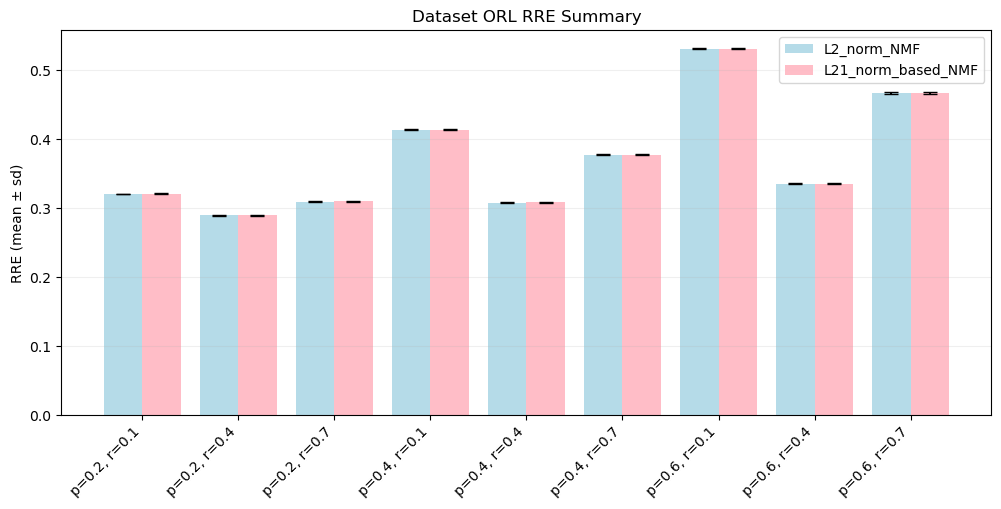

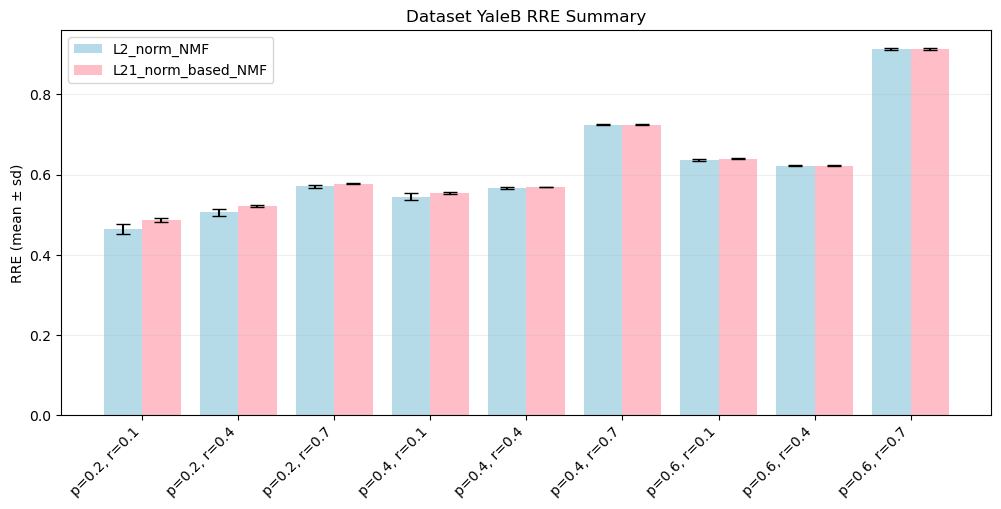

In [119]:
# Summary for the combination of p and r (RRE)
datasets = df_rre["dataset"].unique()

for ds in datasets:
    df_ds = df_rre[df_rre["dataset"] == ds].copy()
    pr_records = []
    prs = df_ds[["p","r"]].drop_duplicates().sort_values(["p","r"]).values

    for ps, rs in prs:
        sub_l2 = df_ds[(df_ds["nmf_method"]=="L2_norm_NMF") &
                       (df_ds["p"]==ps) & (df_ds["r"]==rs)]

        sub_l21 = df_ds[(df_ds["nmf_method"]=="L21_norm_based_NMF") &
                        (df_ds["p"]==ps) & (df_ds["r"]==rs)]

        pr_records.append([
            f"p={ps}, r={rs}",
            "L2",
            float(sub_l2["rre_mean"].values[0]),
            float(sub_l2["rre_sd"].values[0]),
            "L21",
            float(sub_l21["rre_mean"].values[0]),
            float(sub_l21["rre_sd"].values[0]),
        ])

    pr_summary = pd.DataFrame(pr_records, columns=[
        "pr", "L2", "L2_mean", "L2_std",
        "L21", "L21_mean", "L21_std"
    ])
    print(f"\nDataset {ds} RRE Summary")
    print(pr_summary)

    #bar plot
    x = np.arange(len(pr_summary))
    w = 0.4

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, pr_summary["L2_mean"],  yerr=pr_summary["L2_std"],  width=w, capsize=5, label="L2_norm_NMF",color="lightblue",alpha=0.9)
    ax.bar(x + w/2, pr_summary["L21_mean"], yerr=pr_summary["L21_std"], width=w, capsize=5, label="L21_norm_based_NMF",color="lightpink",alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(pr_summary["pr"], rotation=45, ha="right")
    ax.set_ylabel("RRE (mean ± sd)")
    ax.set_title(f"Dataset {ds} RRE Summary")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)

In [53]:
# Function to create table to visualize the result.
def table_visual(X:list):
    df = pd.DataFrame(np.array(X).reshape(3, 3), index=ps, columns=rs)
    print(df)

In [55]:
# Table Visualization
metrics = ["mean","std"]
print('The value of columns is r while the value of index is p.')
for metric, name, method in product(metrics, datasets, methods):
    print('-')
    print(f'RRE {metric} for dataset "{name}" using algorithm "{method}":')
    table_visual(results[(name, method, metric)])

The value of columns is r while the value of index is p.
-
RRE mean for dataset "ORL" using algorithm "L2_norm_NMF":
          0.1       0.4       0.7
0.2  0.320664  0.289690  0.309578
0.4  0.413984  0.308154  0.377594
0.6  0.531442  0.335489  0.466826
-
RRE mean for dataset "ORL" using algorithm "L21_norm_based_NMF":
          0.1       0.4       0.7
0.2  0.320782  0.289907  0.309868
0.4  0.413878  0.308297  0.377838
0.6  0.531275  0.335583  0.467052
-
RRE mean for dataset "YaleB" using algorithm "L2_norm_NMF":
          0.1       0.4       0.7
0.2  0.463253  0.506036  0.570976
0.4  0.544394  0.566930  0.724803
0.6  0.635882  0.621854  0.913228
-
RRE mean for dataset "YaleB" using algorithm "L21_norm_based_NMF":
          0.1       0.4       0.7
0.2  0.486538  0.520992  0.576967
0.4  0.554642  0.568889  0.724711
0.6  0.639322  0.622031  0.912963
-
RRE std for dataset "ORL" using algorithm "L2_norm_NMF":
          0.1       0.4       0.7
0.2  0.000554  0.000583  0.000489
0.4  0.000367 

In [57]:
# Compare algorithm in the same p,r,dataset with mean and std metrics.

def plot_rre():
    # Transfer dict into dataframe
    records = []
    for (dataset, method, metric), values in results.items():
        if metric == "mean":
            stds = results[(dataset, method, "std")]
            for (p, r), mean, std in zip(product(ps, rs), values, stds):
                records.append({
                    "dataset": dataset,
                    "method": method,
                    "p": p,
                    "r": r,
                    "mean": mean,
                    "std": std
                })
    df = pd.DataFrame(records)

    colors = ["#1f77b4", "#ff7f0e"]

    # plot
    for dataset in datasets:
        fig, axes = plt.subplots(
            nrows=1, ncols=len(ps)*len(rs),
            figsize=(3*len(ps)*len(rs), 5), 
            sharey=False
        )

        for k, (p, r) in enumerate(product(ps, rs)):
            ax = axes[k]
            sub = df[(df["dataset"] == dataset) &
                    (df["p"] == p) &
                    (df["r"] == r)]

            x = range(len(methods))
            means = sub.set_index("method").loc[methods]["mean"]
            stds  = sub.set_index("method").loc[methods]["std"]

            for xi, (m, mean, std) in enumerate(zip(methods, means, stds)):
                ax.bar(xi, mean, yerr=std, capsize=5, alpha=0.9,
                    color=colors[xi], label=m if k == 0 else "")
            ax.set_xticks(x)
            ax.set_xticklabels(methods, rotation=45)
            ax.set_title(f"p={p}, r={r}", fontsize=10)
            if k == 0:
                ax.set_ylabel("Mean ± Std")

        plt.suptitle(f"Dataset = {dataset}", fontsize=14)
        plt.tight_layout()
        plt.show()

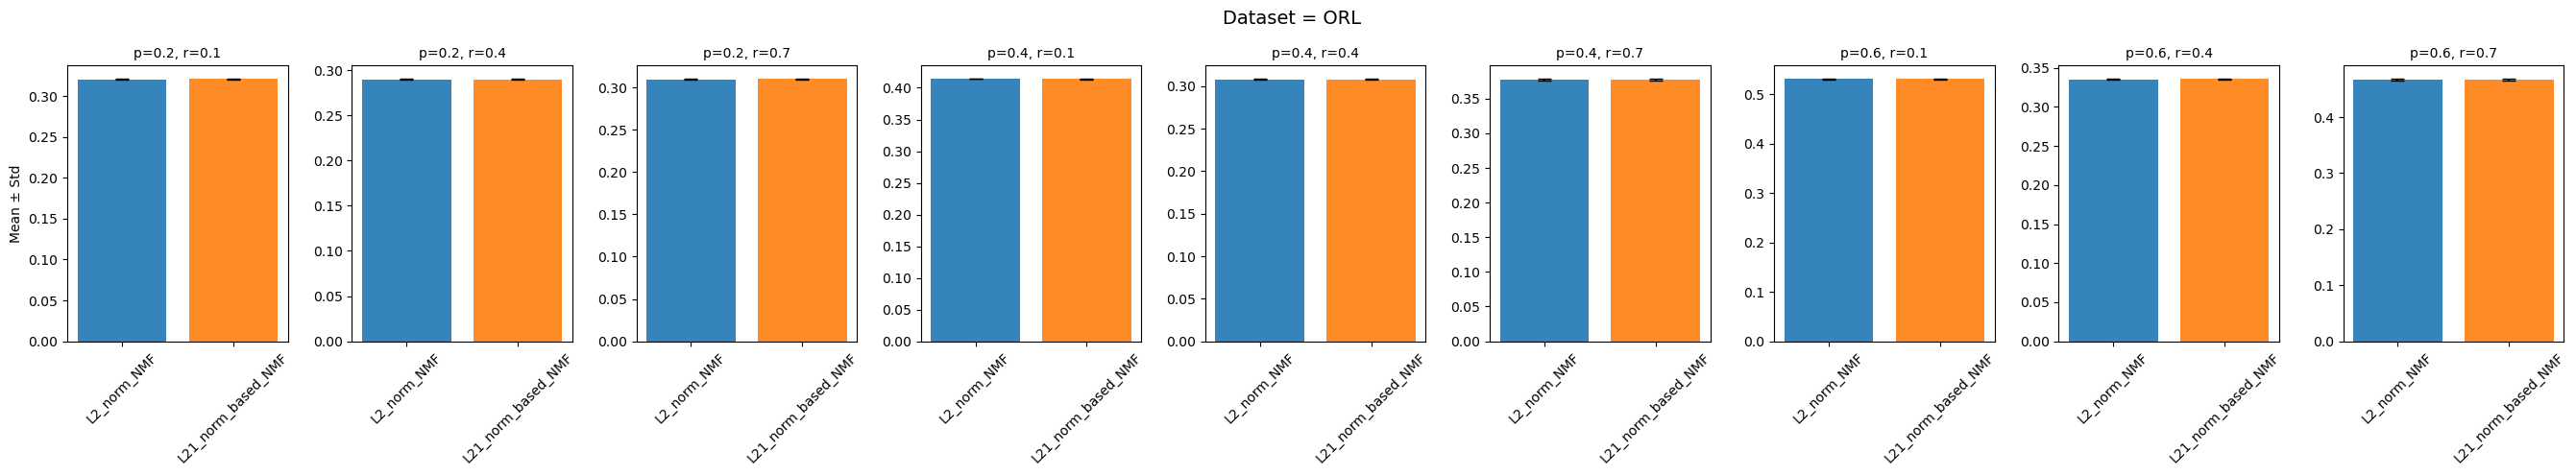

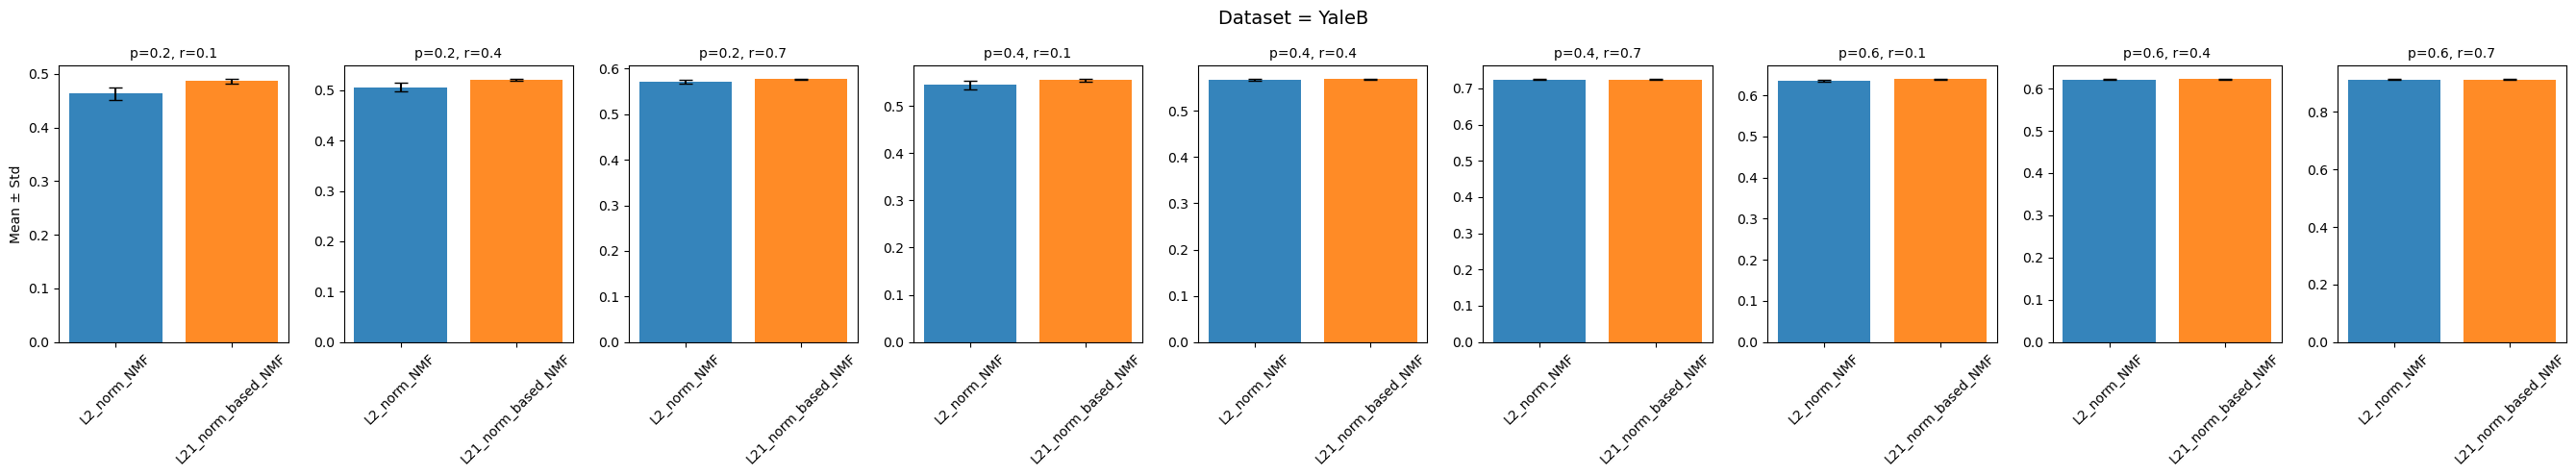

In [59]:
plot_rre()

### 2.2 Evaluate Clustering Performance

1. Accuracy.
    
    $$ Acc(Y, Y_{pred}) = \frac{1}{n}\sum\limits_{i=1}^n 1\{Y_{pred}(i) == Y(i)\}$$
        
2. Normalized Mutual Information (NMI).

    $$ NMI(Y, Y_{pred}) = \frac{2 * I(Y, Y_{pred})}{H(Y) + H(Y_{pred})} $$
    
   where $ I(\cdot,\cdot) $ is mutual information and $ H(\cdot) $ is entropy.

In [97]:
from collections import Counter
from sklearn.cluster import KMeans

def assign_cluster_label(X, Y):
    kmeans = KMeans(n_clusters=len(set(Y))).fit(X)
    Y_pred = np.zeros(Y.shape)
    for i in set(kmeans.labels_):
        ind = kmeans.labels_ == i
        Y_pred[ind] = Counter(Y[ind]).most_common(1)[0][0] # assign label.
    return Y_pred

In [107]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import normalized_mutual_info_score

# Save Acc and NMI records
try:
    acc_nmi_records
except NameError:
    acc_nmi_records = []
    

# Evaluate Acc and NMI

def Acc_NMI(p, r, name:str, method:str, seed = range(5), ratio = 0.9):
    
    if name == "ORL":
        Origin_X,Origin_y = load_data(root = root_ORL, img_resize = img_resize_ORL)
    if name == "YaleB":
        Origin_X,Origin_y = load_data(root = root_YaleB, img_resize = img_resize_YaleB)

    n_samples = Origin_X.shape[1]
    n_train = int(n_samples * ratio)

    acc_record = []
    nmi_record = []

    # Set the seed
    for i in seed:
        print('-')
        print(f'Start random No.{i+1} to evaluate the accuracy.')
        rng = np.random.default_rng(seed=i)
        indices = rng.permutation(n_samples)

        # Collect the ratio of data.
        test_idx = indices[:n_train]
        X_test, y_test = Origin_X[:,test_idx], Origin_y[test_idx]

        # Start caculate.
        V_hat, Y_hat = X_test, y_test

        # add salt & pepper noise
        V_noise = add_salt_pepper(V_hat, p=p, r=r, seed=i, vmax=1.0)

        # factorize noisy data
        if method == "L2_norm_NMF":
            F, G = nmf_standard(V_noise, Y_hat, eps=1e-7, seed=i)
        if method == "L21_norm_based_NMF":
            F, G, history = L21_norm_based_NMF(X = V_noise, y = Y_hat, name = name) 
        

        Y_pred = assign_cluster_label(G.T,Y_hat)

        acc = accuracy_score(Y_hat, Y_pred)
        acc_record.append(acc)
        nmi = normalized_mutual_info_score(Y_hat, Y_pred)
        nmi_record.append(nmi)

        print('Random No.{} Acc(NMI) = {:.4f} ({:.4f})'.format(i+1, acc, nmi))
    
    acc_mean, acc_std = round(float(np.mean(acc_record)),8), round(float(np.std(acc_record)),8)
    nmi_mean, nmi_std = round(float(np.mean(nmi_record)),8), round(float(np.std(nmi_record)),8)

    print('------------')
    print(f'Total random {i+1} times. Using method {method} on dataset {name} with p = {p} & r = {r}.')
    print(f'The mean of acc: {acc_mean}')
    print(f'The std of acc: {acc_std}')
    print(f'The mean of nmi: {nmi_mean}')
    print(f'The std of nmi: {nmi_std}')
    
    acc_nmi_records.append({
        "dataset": name,
        "nmf_method": method,
        "p": float(p),
        "r": float(r),
        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "nmi_mean": nmi_mean,
        "nmi_std": nmi_std
    })

    return acc_mean, acc_std, nmi_mean, nmi_std

In [109]:
# Function to evaluate all dataset and algorithm rre and record

datasets = ["ORL", "YaleB"]
methods = ["L2_norm_NMF","L21_norm_based_NMF"]
ps = [0.2,0.4,0.6]
rs = [0.1,0.4,0.7]

acc_nmi_results = {}

for p, r, name, method in product(ps, rs, datasets, methods):
    acc_mean, acc_std, nmi_mean, nmi_std = Acc_NMI(p = p, r = r, name = name, method = method)
    acc_nmi_results.setdefault((name, method, "mean", "Acc"), []).append(acc_mean)
    acc_nmi_results.setdefault((name, method, "std", "Acc"), []).append(acc_std)
    acc_nmi_results.setdefault((name, method, "mean", "NMI"), []).append(nmi_mean)
    acc_nmi_results.setdefault((name, method, "std", "NMI"), []).append(nmi_std)

-
Start random No.1 to evaluate the accuracy.
Converged after 10 iterations, diff=2.313e+00
Random No.1 Acc(NMI) = 0.2028 (0.3956)
-
Start random No.2 to evaluate the accuracy.
Converged after 10 iterations, diff=2.299e+00
Random No.2 Acc(NMI) = 0.1806 (0.3631)
-
Start random No.3 to evaluate the accuracy.
Converged after 10 iterations, diff=2.358e+00
Random No.3 Acc(NMI) = 0.1972 (0.3789)
-
Start random No.4 to evaluate the accuracy.
Converged after 10 iterations, diff=2.351e+00
Random No.4 Acc(NMI) = 0.2083 (0.3965)
-
Start random No.5 to evaluate the accuracy.
Converged after 10 iterations, diff=2.334e+00
Random No.5 Acc(NMI) = 0.2083 (0.3986)
------------
Total random 5 times. Using method L2_norm_NMF on dataset ORL with p = 0.2 & r = 0.1.
The mean of acc: 0.19944444
The std of acc: 0.01030402
The mean of nmi: 0.38655047
The std of nmi: 0.01365801
-
Start random No.1 to evaluate the accuracy.
-
Using L_21_Norm_NMF_Algorithm on dataset ORL.
Reached the max iteration. Last convergenc

In [111]:
# Summary for acc and NMI records
df_acc_nmi = pd.DataFrame(
    acc_nmi_records,
    columns=["dataset","nmf_method","p","r","acc_mean","acc_std","nmi_mean","nmi_std"]
).sort_values(["dataset","nmf_method","p","r"])

print(df_acc_nmi)

   dataset          nmf_method    p    r  acc_mean   acc_std  nmi_mean  \
1      ORL  L21_norm_based_NMF  0.2  0.1  0.196111  0.009558  0.377815   
5      ORL  L21_norm_based_NMF  0.2  0.4  0.195000  0.010153  0.373296   
9      ORL  L21_norm_based_NMF  0.2  0.7  0.182222  0.005152  0.363146   
13     ORL  L21_norm_based_NMF  0.4  0.1  0.192222  0.011027  0.380735   
17     ORL  L21_norm_based_NMF  0.4  0.4  0.179444  0.007577  0.356278   
21     ORL  L21_norm_based_NMF  0.4  0.7  0.179444  0.008352  0.349536   
25     ORL  L21_norm_based_NMF  0.6  0.1  0.185000  0.006713  0.355879   
29     ORL  L21_norm_based_NMF  0.6  0.4  0.177222  0.004779  0.361689   
33     ORL  L21_norm_based_NMF  0.6  0.7  0.181111  0.008854  0.362815   
0      ORL         L2_norm_NMF  0.2  0.1  0.199444  0.010304  0.386550   
4      ORL         L2_norm_NMF  0.2  0.4  0.188333  0.008854  0.372471   
8      ORL         L2_norm_NMF  0.2  0.7  0.186667  0.002079  0.363251   
12     ORL         L2_norm_NMF  0.4  0

In [121]:
# Summary for the combination of p and r (Acc / NMI)
datasets = df_acc_nmi["dataset"].unique()

for ds in datasets:
    df_ds = df_acc_nmi[df_acc_nmi["dataset"] == ds]
    prs = df_ds[["p","r"]].drop_duplicates().sort_values(["p","r"]).values

    # Accuracy Summary
    acc_records = []
    for ps, rs in prs:
        sub_l2 = df_ds[(df_ds["nmf_method"]=="L2_norm_NMF") &
                       (df_ds["p"]==ps) & (df_ds["r"]==rs)]
        sub_l21 = df_ds[(df_ds["nmf_method"]=="L21_norm_based_NMF") &
                        (df_ds["p"]==ps) & (df_ds["r"]==rs)]
        acc_records.append([
            f"p={ps}, r={rs}",
            "L2",
            float(sub_l2["acc_mean"].values[0]),
            float(sub_l2["acc_std"].values[0]),
            "L21",
            float(sub_l21["acc_mean"].values[0]),
            float(sub_l21["acc_std"].values[0]),
        ])
    acc_summary = pd.DataFrame(acc_records, columns=[
        "pr", "L2", "L2_mean", "L2_std",
        "L21", "L21_mean", "L21_std"
    ])
    print(f"\nDataset {ds} Accuracy Summary")
    print(acc_summary)
    
    # NMI Summary
    nmi_records = []
    for ps, rs in prs:
        sub_l2 = df_ds[(df_ds["nmf_method"]=="L2_norm_NMF") &
                       (df_ds["p"]==ps) & (df_ds["r"]==rs)]
        sub_l21 = df_ds[(df_ds["nmf_method"]=="L21_norm_based_NMF") &
                        (df_ds["p"]==ps) & (df_ds["r"]==rs)]
        nmi_records.append([
            f"p={ps}, r={rs}",
            "L2",
            float(sub_l2["nmi_mean"].values[0]),
            float(sub_l2["nmi_std"].values[0]),
            "L21",
            float(sub_l21["nmi_mean"].values[0]),
            float(sub_l21["nmi_std"].values[0]),
        ])
    nmi_summary = pd.DataFrame(nmi_records, columns=[
        "pr", "L2", "L2_mean", "L2_std",
        "L21", "L21_mean", "L21_std"
    ])
    print(f"\nDataset {ds} NMI Summary")
    print(nmi_summary)


Dataset ORL Accuracy Summary
             pr  L2   L2_mean    L2_std  L21  L21_mean   L21_std
0  p=0.2, r=0.1  L2  0.199444  0.010304  L21  0.196111  0.009558
1  p=0.2, r=0.4  L2  0.188333  0.008854  L21  0.195000  0.010153
2  p=0.2, r=0.7  L2  0.186667  0.002079  L21  0.182222  0.005152
3  p=0.4, r=0.1  L2  0.193333  0.004513  L21  0.192222  0.011027
4  p=0.4, r=0.4  L2  0.184444  0.004513  L21  0.179444  0.007577
5  p=0.4, r=0.7  L2  0.183333  0.007857  L21  0.179444  0.008352
6  p=0.6, r=0.1  L2  0.180556  0.005827  L21  0.185000  0.006713
7  p=0.6, r=0.4  L2  0.182778  0.005666  L21  0.177222  0.004779
8  p=0.6, r=0.7  L2  0.176111  0.004843  L21  0.181111  0.008854

Dataset ORL NMI Summary
             pr  L2   L2_mean    L2_std  L21  L21_mean   L21_std
0  p=0.2, r=0.1  L2  0.386550  0.013658  L21  0.377815  0.010843
1  p=0.2, r=0.4  L2  0.372471  0.011550  L21  0.373296  0.020475
2  p=0.2, r=0.7  L2  0.363251  0.006169  L21  0.363146  0.006836
3  p=0.4, r=0.1  L2  0.370024  0.01

In [103]:
# Table Visualization
metrics = ["mean","std"]
acc_nmi_s = ["Acc","NMI"]
print('The value of columns is r while the value of index is p.')
for metric, name, method, acc_nmi in product(metrics, datasets, methods, acc_nmi_s):
    print('-')
    print(f'{acc_nmi} {metric} for dataset "{name}" using algorithm "{method}":')
    table_visual(acc_nmi_results[(name, method, metric, acc_nmi)])

The value of columns is r while the value of index is p.
-
Acc mean for dataset "ORL" using algorithm "L2_norm_NMF":
          0.1       0.4       0.7
0.2  0.199444  0.188333  0.186667
0.4  0.193333  0.184444  0.183333
0.6  0.180556  0.182778  0.176111
-
NMI mean for dataset "ORL" using algorithm "L2_norm_NMF":
          0.1       0.4       0.7
0.2  0.386550  0.372471  0.363251
0.4  0.370024  0.359230  0.359155
0.6  0.361529  0.361778  0.351598
-
Acc mean for dataset "ORL" using algorithm "L21_norm_based_NMF":
          0.1       0.4       0.7
0.2  0.196111  0.195000  0.182222
0.4  0.192222  0.179444  0.179444
0.6  0.185000  0.177222  0.181111
-
NMI mean for dataset "ORL" using algorithm "L21_norm_based_NMF":
          0.1       0.4       0.7
0.2  0.377815  0.373296  0.363146
0.4  0.380735  0.356278  0.349536
0.6  0.355879  0.361689  0.362815
-
Acc mean for dataset "YaleB" using algorithm "L2_norm_NMF":
          0.1       0.4       0.7
0.2  0.090331  0.087201  0.084346
0.4  0.088766  

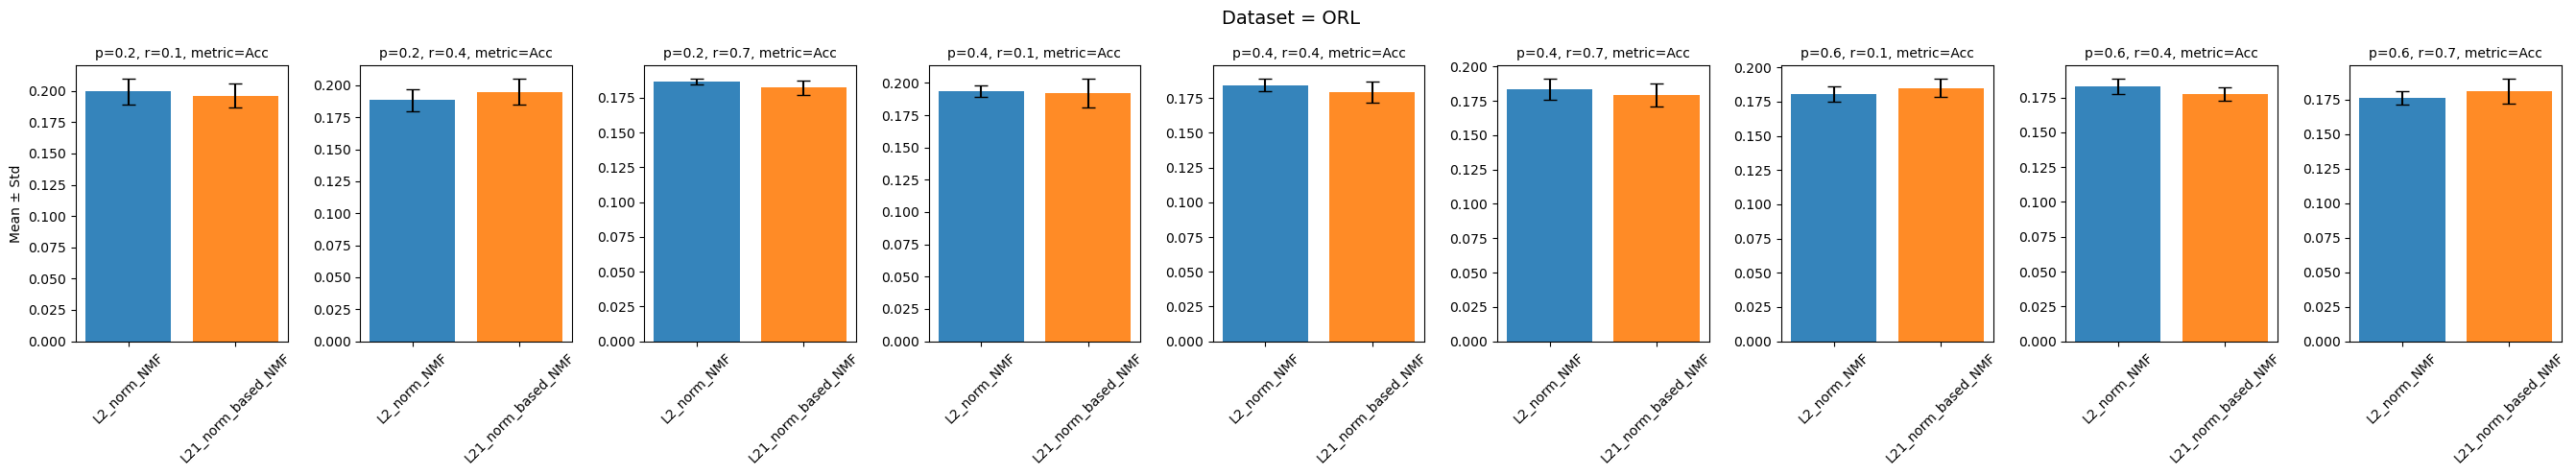

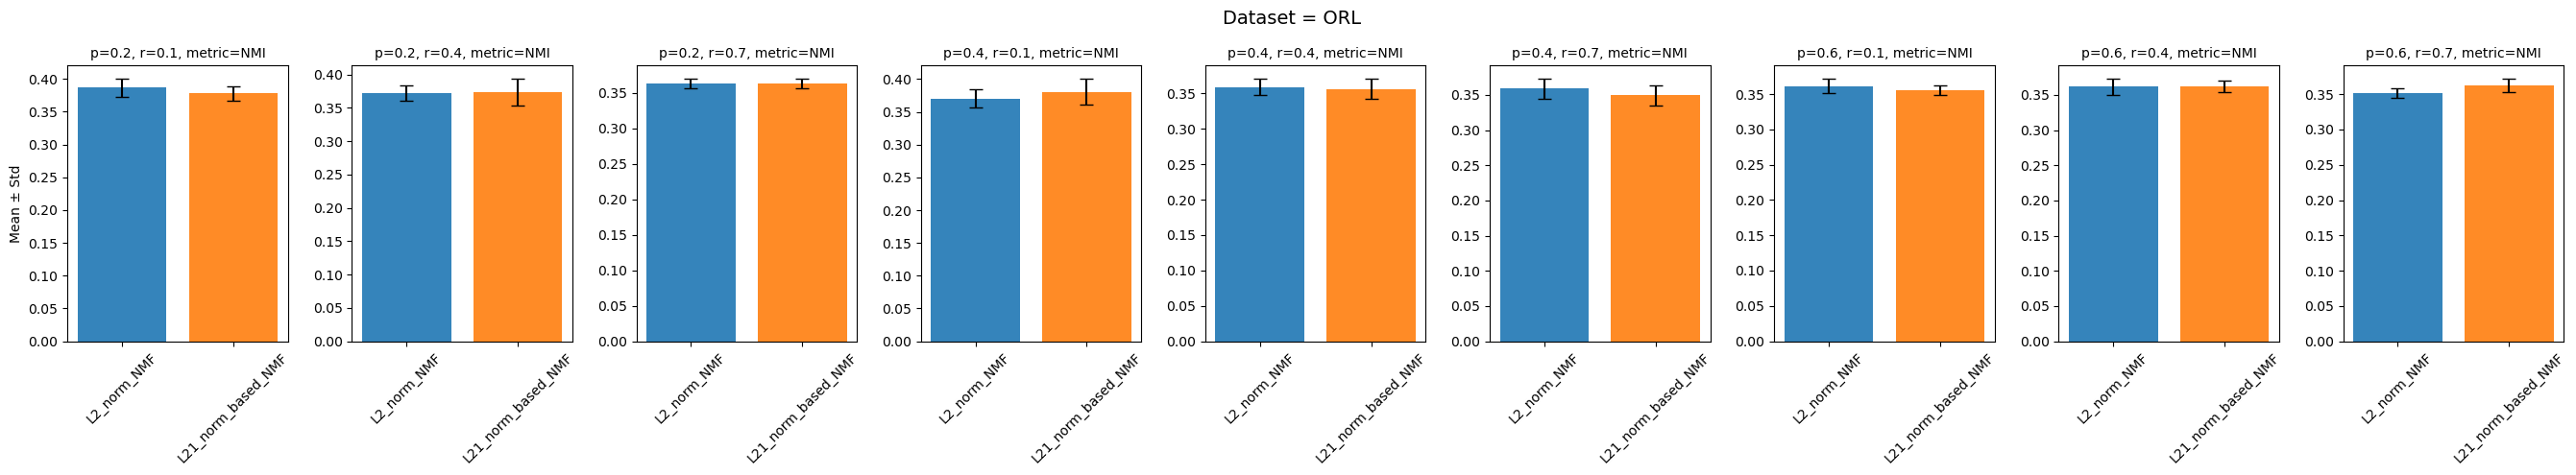

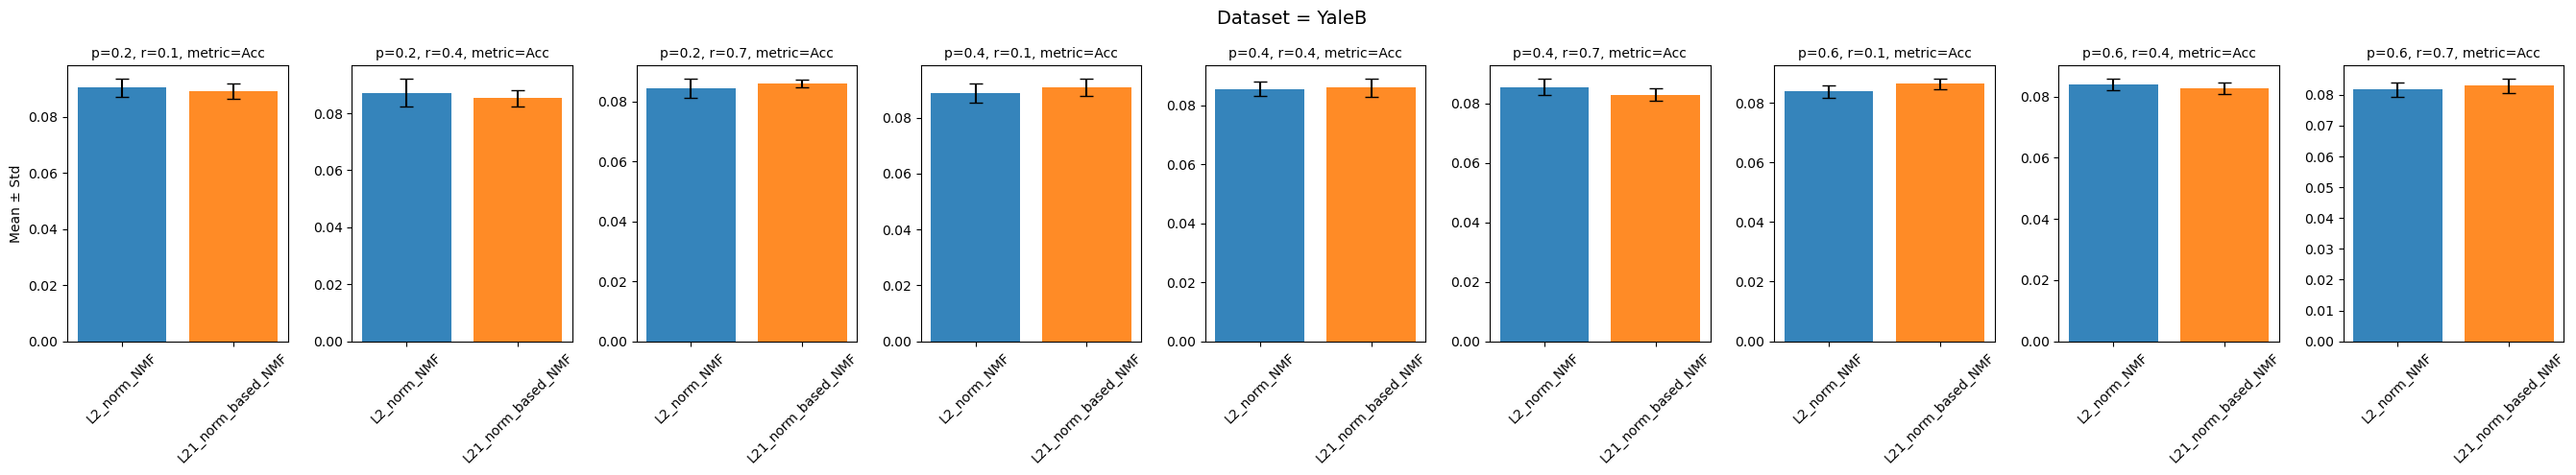

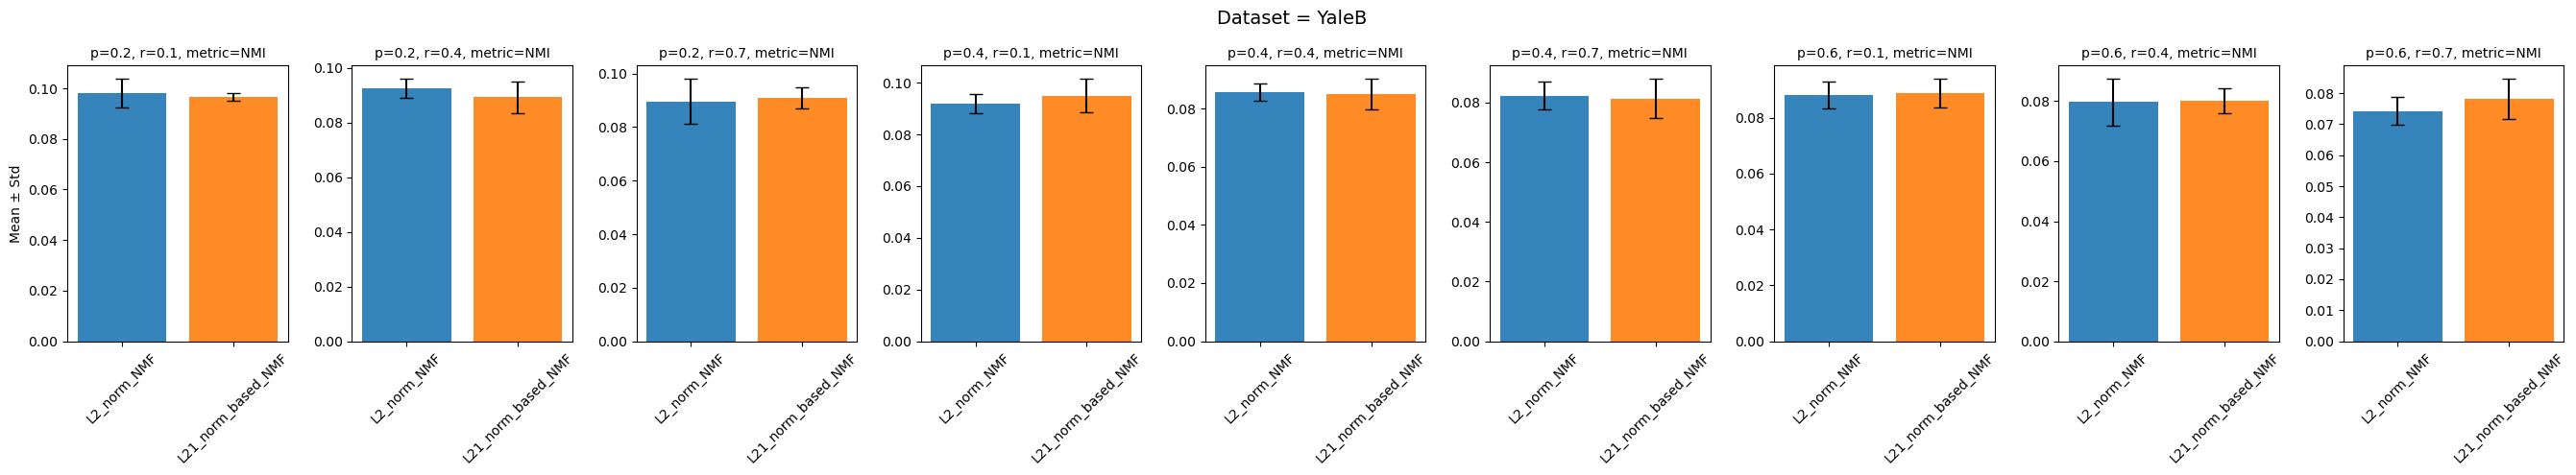

In [105]:
# Compare algorithm in the same p,r,dataset with mean and std metrics.

def plot_acc_nmi():
    # Transfer dict into dataframe
    records = []
    for (dataset, method, metric, acc_nmi), values in acc_nmi_results.items():
        if metric == "mean":
            stds = acc_nmi_results[(dataset, method, "std", acc_nmi)]
            for (p, r), mean, std in zip(product(ps, rs), values, stds):
                records.append({
                    "dataset": dataset,
                    "method": method,
                    "p": p,
                    "r": r,
                    "mean": mean,
                    "std": std,
                    "acc_nmi": acc_nmi
                })
    df = pd.DataFrame(records)

    colors = ["#1f77b4", "#ff7f0e"]

    # plot
    for dataset in datasets:
        for acc_nmi in acc_nmi_s:
            fig, axes = plt.subplots(
                nrows=1, ncols=len(ps)*len(rs),
                figsize=(3*len(ps)*len(rs), 5), 
                sharey=False
            )

            for k, (p, r) in enumerate(product(ps, rs)):
                ax = axes[k]
                sub = df[(df["dataset"] == dataset) &
                        (df["p"] == p) &
                        (df["r"] == r) &
                        (df["acc_nmi"] == acc_nmi)]

                x = range(len(methods))
                means = sub.set_index("method").loc[methods]["mean"]
                stds  = sub.set_index("method").loc[methods]["std"]

                for xi, (m, mean, std) in enumerate(zip(methods, means, stds)):
                    ax.bar(xi, mean, yerr=std, capsize=5, alpha=0.9,
                        color=colors[xi], label=m if k == 0 else "")
                ax.set_xticks(x)
                ax.set_xticklabels(methods, rotation=45)
                ax.set_title(f"p={p}, r={r}, metric={acc_nmi}", fontsize=10)
                if k == 0:
                    ax.set_ylabel("Mean ± Std")

            plt.suptitle(f"Dataset = {dataset}", fontsize=14)
            plt.tight_layout()
            plt.show()

plot_acc_nmi()